# Fig6

In [1]:
from zebrafish_ms2_paper.gillespie_simulations_delay import Params, simulate_multiple_copies, sim_ms2, hill_function
from zebrafish_ms2_paper.trace_analysis import binarize_trace, get_on_and_off_times, get_burst_durations, get_burst_inactive_durations, extract_traces
from zebrafish_ms2_paper.utils import pboc_rc, style_axes, colors, fontsize
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
import numpy as np
from multiprocessing import Pool
import pandas as pd
import pickle
from copy import deepcopy
from functools import partial
from scipy.stats import wasserstein_distance
from scipy.ndimage import gaussian_filter

In [2]:
#pboc_rc['ytick.major.size'] = 1
#pboc_rc['ytick.major.width'] = 1

rcParams.update(pboc_rc)
rcParams['pdf.fonttype'] = 42

In [3]:
colors

{'green': '#7AA974',
 'light_green': '#BFD598',
 'pale_green': '#DCECCB',
 'yellow': '#EAC264',
 'light_yellow': '#F3DAA9',
 'pale_yellow': '#FFEDCE',
 'blue': '#738FC1',
 'light_blue': '#A9BFE3',
 'pale_blue': '#C9D7EE',
 'red': '#D56C55',
 'light_red': '#E8B19D',
 'pale_red': '#F1D4C9',
 'purple': '#AB85AC',
 'light_purple': '#D4C2D9',
 'dark_green': '#7E9D90',
 'dark_brown': '#905426'}

In [4]:
fontsize = 9
linewidth = 2
run_sim = True
n_replicates = 15
markersize = 8
bins = np.linspace(3, 55, 12)


In [5]:
%matplotlib qt

In [9]:
"""function for computing interval distributions"""
def compute_burst_intervals(p, sigma=0.2, detection_threshold=None, detection_threshold_mode='abs', elongation_time = 0.29, delta_t=1.0):
    """detection threshold: in 'abs' mode, pass an absolute number for threshold simulated ms2 signal. in 'fraction' mode
                            detection_threshold gets multiplied by the scale of MS2 signal, defined below."""
    X, tvec, p = simulate_multiple_copies(p)
    burn_in_time = 0
    X = X[burn_in_time:]
    production_rate = p.transcription_rate_0 + p.transcription_rate_1 * hill_function(X[:,-1], p.KD_transcription_rate, p.n)
    state = X[:, 0]
    
    # MS2 memory parameter
    w = elongation_time / delta_t
    
    relevant_production_rate = production_rate[np.where(tvec > burn_in_time)[0]]
    m = np.mean(np.log10(relevant_production_rate[relevant_production_rate > 0]))
    s = np.std(np.log10(relevant_production_rate[relevant_production_rate > 0]))
    if detection_threshold is None:
        detection_threshold = 0.22 * 10 ** (m + s) * w
    if detection_threshold_mode == 'fraction':
        detection_threshold = detection_threshold * 10 ** (m + s) * w

    ms2, uniform_times = sim_ms2(state, tvec, production_rate, w, delta_t, sigma, detection_threshold)
    
    inferred_state = binarize_trace(ms2, uniform_times, thresh=1e-1, window_size=3)
    on_times, off_times = get_on_and_off_times(inferred_state, uniform_times)
    active_durations  = get_burst_durations(on_times, off_times)
    inactive_durations = get_burst_inactive_durations(on_times, off_times)
    periods = np.diff(on_times)
       
    return active_durations, inactive_durations, periods

def init_pool_processes():
    np.random.seed()
    

"""more functions for computing interval distributions. we also need func and init_pool_processes from the cell above."""
def compute_distributions(traces, bins):
    pulse_periods = []
    pulse_durations =[]
    pulse_quiets = []
    for i, trace in enumerate(traces):
        t_arr, inten_arr, nucleus = trace
        t_arr = non_blank_timepoints[t_arr.astype('int')]
        state = binarize_trace(inten_arr, t_arr, thresh=1.0, window_size=5)
        on_times, off_times = get_on_and_off_times(state, t_arr)
        if len(on_times) > 2:
            these_pulse_periods = np.diff(on_times)
            these_quiets = get_burst_inactive_durations(on_times, off_times)
            pulse_periods.extend([p for p in these_pulse_periods])
            these_pulse_durations = get_burst_durations(on_times, off_times)
            pulse_durations.extend([p for p in these_pulse_durations])
            pulse_quiets.extend([p for p in these_quiets])
            
    counts, bins = np.histogram(pulse_durations, bins=bins)
    prob_dens_durations = counts / np.sum(counts) / np.diff(bins)
    
    counts, bins = np.histogram(pulse_quiets, bins=bins)
    prob_dens_quiets = counts / np.sum(counts) / np.diff(bins)
            
    return prob_dens_durations, prob_dens_quiets


def bootstrap_distributions(traces, bins, n_bootstraps):
    duration_dist_arr = np.zeros((n_bootstraps, len(bins) - 1))
    quiet_dist_arr = np.zeros((n_bootstraps, len(bins) - 1))
    for i in range(int(n_bootstraps)):
        these_ids = np.random.randint(0, len(traces), len(traces), dtype='int')
        these_traces = [traces[j] for j in these_ids]
        
        duration_dist_arr[i], quiet_dist_arr[i] = compute_distributions(these_traces, bins)

    return duration_dist_arr, quiet_dist_arr 


def bootstrap_simulated_distributions(intervals, bins, n_bootstraps):
    interval_dist_arr = np.zeros((n_bootstraps, len(bins) - 1))
    for i in range(int(n_bootstraps)):
        these_ids = np.random.randint(0, len(intervals), len(intervals), dtype='int')
        these_intervals = [intervals[j] for j in these_ids]
        
        counts, bins = np.histogram(these_intervals, bins=bins)
        interval_dist_arr[i] = counts / np.sum(counts) / np.diff(bins)
        
    return interval_dist_arr 


def exp_loss(x, size=10000):
    """compute wass1 distance between a sample distribution (samples = x) and the max likelihood exponential fit"""
    scale = 1 / np.mean(x)
    exp_rnds = np.random.exponential(scale=scale, size=size)
    return wasserstein_distance(x, exp_rnds)


def plot_interval_dists(intervals, 
                        bins,
                        ax=None,
                        xlabel=None, 
                        ylabel=None, 
                        xticks=(0, 15, 30), 
                        yticks=(0, 0.05, 0.10),
                        n_bootstraps=100,
                        title=None,
                        color='k',
                       ):
    if ax is None:
        f, ax = plt.subplots()
    counts, bins = np.histogram(intervals, bins=bins)
    prob_dens = counts / np.sum(counts) / np.diff(bins)
    interval_dist_arr = bootstrap_simulated_distributions(intervals, bins, n_bootstraps=n_bootstraps)
    prob_dens_uncertainty = np.std(interval_dist_arr, axis=0)

    ax.fill_between(bins[:-1], prob_dens - prob_dens_uncertainty, prob_dens + prob_dens_uncertainty,
                   facecolor=color, alpha=0.5)
    ax.plot(bins[:-1], prob_dens, '-', linewidth=linewidth, color=color)
    
    if xlabel is None:
        xtick_labels = []
    else:
        xtick_labels = xticks
    if ylabel is None:
        ytick_labels = []
    else:
        ytick_labels = yticks
    ax.set_xticks(xticks, labels=xtick_labels)
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_yticks(yticks, labels=ytick_labels)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    if title is not None:
        ax.set_title(title, fontsize=fontsize, fontweight='bold')
        
    ax = style_axes(ax, fontsize=fontsize)
    
    return ax, prob_dens

        

## Run simulations
Here's the code for running the simulations that produce the interval distributions. To just make the plots skip ahead to where the data is loaded in.

In [7]:
"""parameters"""
detection_threshold_arr = np.linspace(0, 0.9, 10)
noise_arr = np.linspace(0, 1, 9)
size = 10000

In [197]:
"""frequency regulation"""
save = True
active_loss_arr = np.zeros((len(detection_threshold_arr), len(noise_arr)))
inactive_loss_arr = np.zeros((len(detection_threshold_arr), len(noise_arr)))

if run_sim:
    counter = 0
    p = Params()
    p.initial_state = np.array([1])
    p.Tmax = 240
    p.k_off0 = 0.08
    p.k_off1 = 0.0
    p.k_on0 = 0.0
    p.k_on1 = 0.5
    p.transcription_rate_0 = 10

    p.translation_rate = 4.5
    p.transcription_rate_1 = 0

    p.mrna_decay_rate = 0.23
    p.protein_decay_rate = 0.23

    p.delay = 0.0

    p.KD_k_on = 80
    p.n = 3

    p_arr = [p] * n_replicates
    
    # for variability in decay rate
    decay_scale = 0
    
    for j in range(len(detection_threshold_arr)):
        print(f'{j} of {len(detection_threshold_arr) - 1}')
        for k in range(len(noise_arr)):
            if counter > 0:
                continue
            for i in range(len(p_arr)):
                tmp_p = deepcopy(p_arr[i])
                tmp_p.protein_decay_rate = np.clip(np.random.normal(loc=0.23, scale=decay_scale), a_min=0, a_max=np.inf)
                p_arr[i] = tmp_p

            func = partial(compute_burst_intervals, 
                           detection_threshold=detection_threshold_arr[j], 
                           detection_threshold_mode='fraction', 
                           sigma=noise_arr[k])
            with Pool(processes=15, initializer=init_pool_processes) as pool:
                res = pool.map(func, p_arr)

            active_durations = [item for sublist in res for item in sublist[0]]
            inactive_durations = [item for sublist in res for item in sublist[1]]
            periods = [item for sublist in res for item in sublist[2]]

            active_loss = exp_loss(active_durations, size=size)
            inactive_loss = exp_loss(inactive_durations, size=size)
            if save:
                out = {'active_durations': active_durations,
                      'inactive_durations': inactive_durations,
                      'periods': periods,
                      'detection_threshold': detection_threshold_arr[j],
                      'noise_strength': noise_arr[k],
                      'active_loss': active_loss,
                      'inactive_loss': inactive_loss}
                with open(f'/home/brandon/Documents/Code/zebrafish-ms2-paper/data/parameter_sweeps/k_on/{counter}.pkl', 'wb') as f:
                    pickle.dump(out, f)
            
            active_loss_arr[j, k] = active_loss
            inactive_loss_arr[j, k] = inactive_loss
            counter += 1


0 of 9
1 of 9
2 of 9
3 of 9
4 of 9
5 of 9
6 of 9
7 of 9
8 of 9
9 of 9


## Plot grid of active intervals

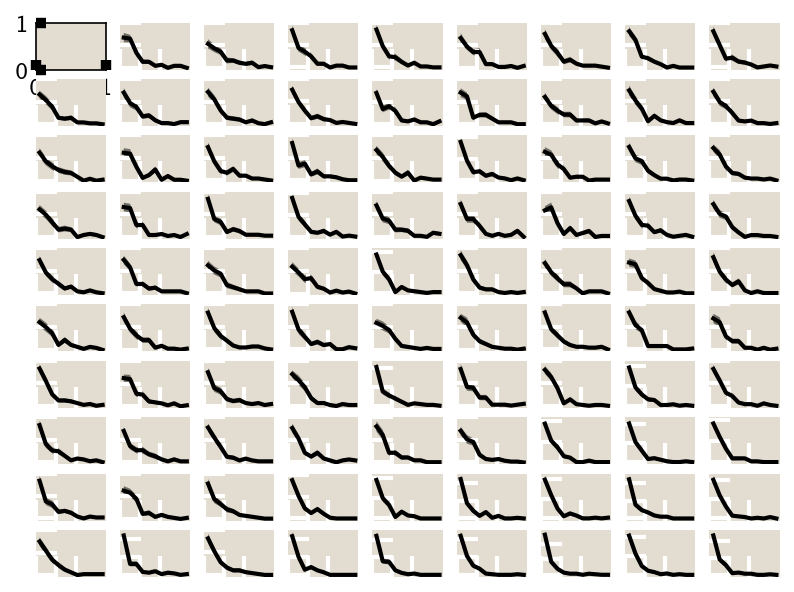

In [10]:
counter = 0
fig, axs = plt.subplots(len(detection_threshold_arr), len(noise_arr))
for j in range(len(detection_threshold_arr)):
    for k in range(len(noise_arr)):
        if counter == 0:
            counter += 1
            continue
        with open(f'/home/brandon/Documents/Code/zebrafish-ms2-paper/data/parameter_sweeps/k_on/{counter}.pkl', 'rb') as file:
            data = pickle.load(file)
        active_durations = data['active_durations']
        _, prob_dens = plot_interval_dists(active_durations, bins, ax=axs[j, k])
        counter += 1    

## Plot grid of inactive intervals

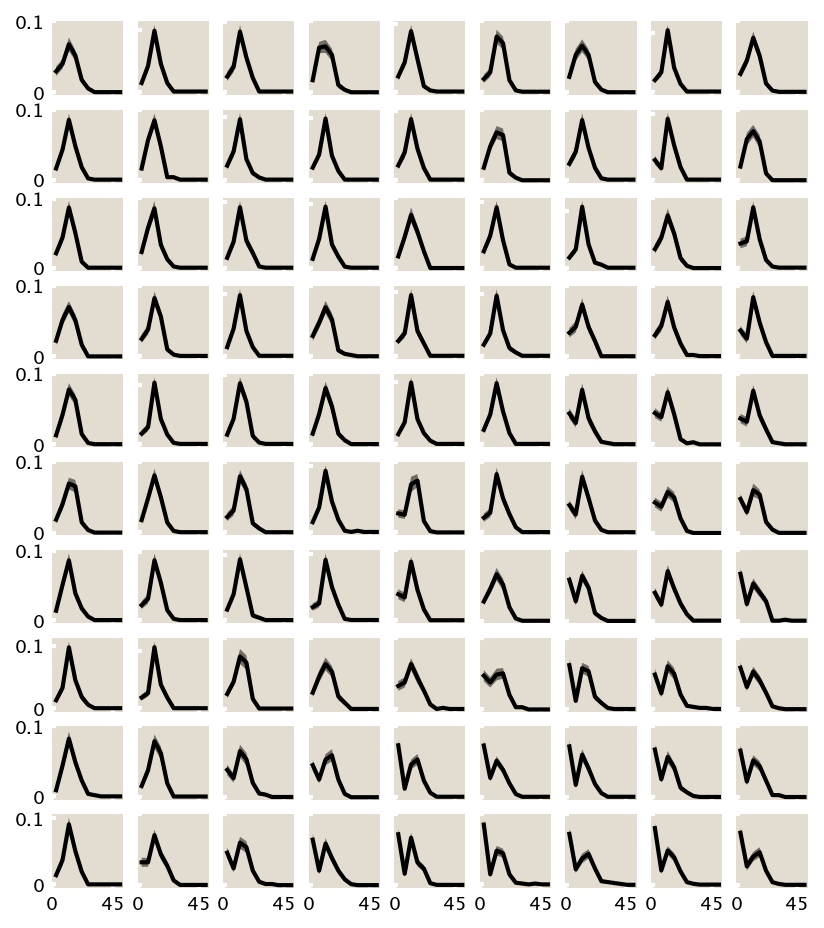

In [11]:
counter = 0
fig, axs = plt.subplots(len(detection_threshold_arr), len(noise_arr), figsize=(6.5, 7.5))
fontsize = 9
ratio_arr = np.zeros((len(detection_threshold_arr), len(noise_arr)))
xticks = (0, 45)
yticks = (0, 0.1)
for j in range(len(detection_threshold_arr)):
    for k in range(len(noise_arr)):
        with open(f'/home/brandon/Documents/Code/zebrafish-ms2-paper/data/parameter_sweeps/k_on/{counter}.pkl', 'rb') as file:
            data = pickle.load(file)
        durations = data['inactive_durations']
        _, prob_dens = plot_interval_dists(durations, bins, ax=axs[j, k], xticks=xticks, yticks=yticks)
        #_, prob_dens = plot_interval_dists(inactive_durations, bins, ax=axs[j, k], title=f'x={detection_threshold_arr[j]:.1f}, $\sigma$={noise_arr[k]:.1f}')
        ratio_arr[j, k] = np.max(prob_dens) / prob_dens[0]
        axs[j, k].tick_params(length=2)
        if k == 0:
            axs[j, k].set_yticks(yticks, labels=yticks)
            
        if j == len(detection_threshold_arr) - 1:
            axs[j, k].set_xticks(xticks, labels=xticks)
        counter += 1

In [202]:
#plt.savefig(r'/home/brandon/Documents/Code/zebrafish-ms2-paper/figures/k_on-inactive.pdf')

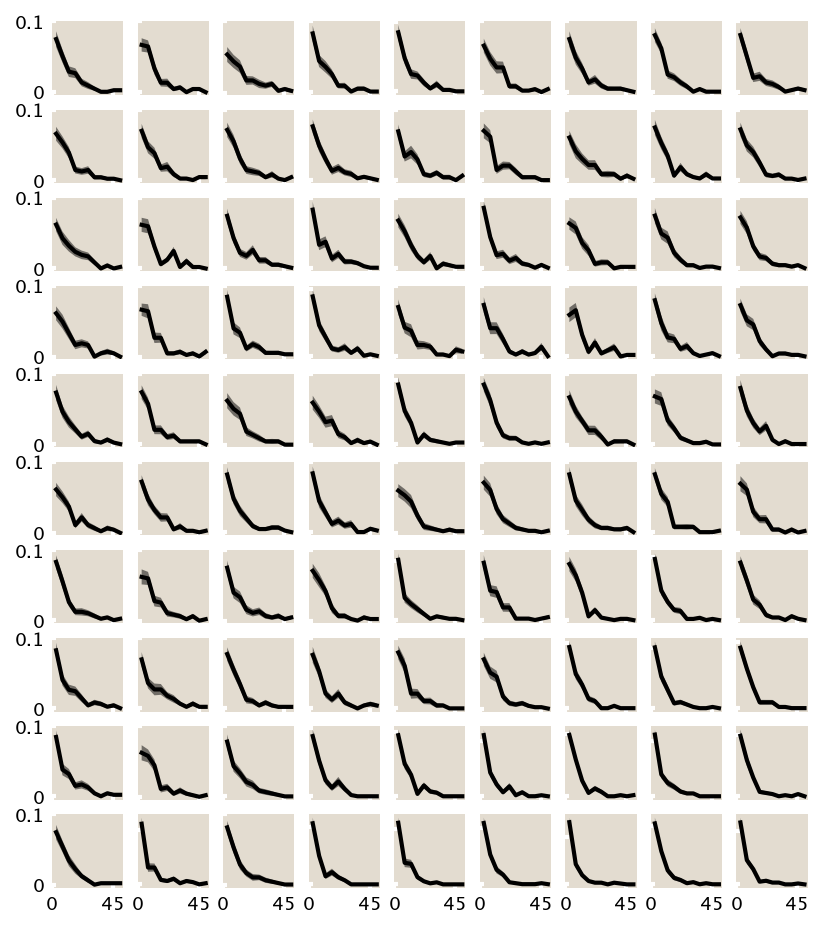

In [12]:
counter = 0
fig, axs = plt.subplots(len(detection_threshold_arr), len(noise_arr), figsize=(6.5, 7.5))
fontsize = 9
ratio_arr = np.zeros((len(detection_threshold_arr), len(noise_arr)))
xticks = (0, 45)
yticks = (0, 0.1)
for j in range(len(detection_threshold_arr)):
    for k in range(len(noise_arr)):
        with open(f'/home/brandon/Documents/Code/zebrafish-ms2-paper/data/parameter_sweeps/k_on/{counter}.pkl', 'rb') as file:
            data = pickle.load(file)
        durations = data['active_durations']
        _, prob_dens = plot_interval_dists(durations, bins, ax=axs[j, k], xticks=xticks, yticks=yticks)
        #_, prob_dens = plot_interval_dists(inactive_durations, bins, ax=axs[j, k], title=f'x={detection_threshold_arr[j]:.1f}, $\sigma$={noise_arr[k]:.1f}')
        ratio_arr[j, k] = np.max(prob_dens) / prob_dens[0]
        axs[j, k].tick_params(length=2)
        if k == 0:
            axs[j, k].set_yticks(yticks, labels=yticks)
            
        if j == len(detection_threshold_arr) - 1:
            axs[j, k].set_xticks(xticks, labels=xticks)
        counter += 1

In [201]:
#plt.savefig(r'/home/brandon/Documents/Code/zebrafish-ms2-paper/figures/k_on-active.pdf')

In [53]:
"""duration regulation"""
save = True
active_loss_arr = np.zeros((len(detection_threshold_arr), len(noise_arr)))
inactive_loss_arr = np.zeros((len(detection_threshold_arr), len(noise_arr)))

if run_sim:
    counter = 0
    p = Params()
    p.initial_state = np.array([1])
    p.Tmax = 240
    p.k_off0 = 0.0
    p.k_off1 = 0.4
    p.k_on0 = 0.055
    p.k_on1 = 0.0
    p.transcription_rate_0 = 10

    p.translation_rate = 4.5
    p.transcription_rate_1 = 0

    p.mrna_decay_rate = 0.23
    p.protein_decay_rate = 0.23
    p.delay = 0

    p.KD_k_on = 10
    p.KD_k_off = 1100
    p.n = 3

    p_arr = [p] * n_replicates
    decay_scale = 0
    
    for j in range(len(detection_threshold_arr)):
        print(f'{j} of {len(detection_threshold_arr) - 1}')
        for k in range(len(noise_arr)):
            for i in range(len(p_arr)):
                tmp_p = deepcopy(p_arr[i])
                tmp_p.protein_decay_rate = np.clip(np.random.normal(loc=0.23, scale=decay_scale), a_min=0, a_max=np.inf)
                p_arr[i] = tmp_p

            func = partial(compute_burst_intervals, 
                           detection_threshold=detection_threshold_arr[j], 
                           detection_threshold_mode='fraction', 
                           sigma=noise_arr[k])
            with Pool(processes=15, initializer=init_pool_processes) as pool:
                res = pool.map(func, p_arr)

            active_durations = [item for sublist in res for item in sublist[0]]
            inactive_durations = [item for sublist in res for item in sublist[1]]
            periods = [item for sublist in res for item in sublist[2]]

            active_loss = exp_loss(active_durations, size=size)
            inactive_loss = exp_loss(inactive_durations, size=size)
            if save:
                out = {'active_durations': active_durations,
                      'inactive_durations': inactive_durations,
                      'periods': periods,
                      'detection_threshold': detection_threshold_arr[j],
                      'noise_strength': noise_arr[k],
                      'active_loss': active_loss,
                      'inactive_loss': inactive_loss}
                with open(f'/home/brandon/Documents/Code/zebrafish-ms2-paper/data/parameter_sweeps/k_off/{counter}.pkl', 'wb') as f:
                    pickle.dump(out, f)
            
            active_loss_arr[j, k] = active_loss
            inactive_loss_arr[j, k] = inactive_loss
            counter += 1


0 of 9
1 of 9
2 of 9
3 of 9
4 of 9
5 of 9
6 of 9
7 of 9
8 of 9
9 of 9


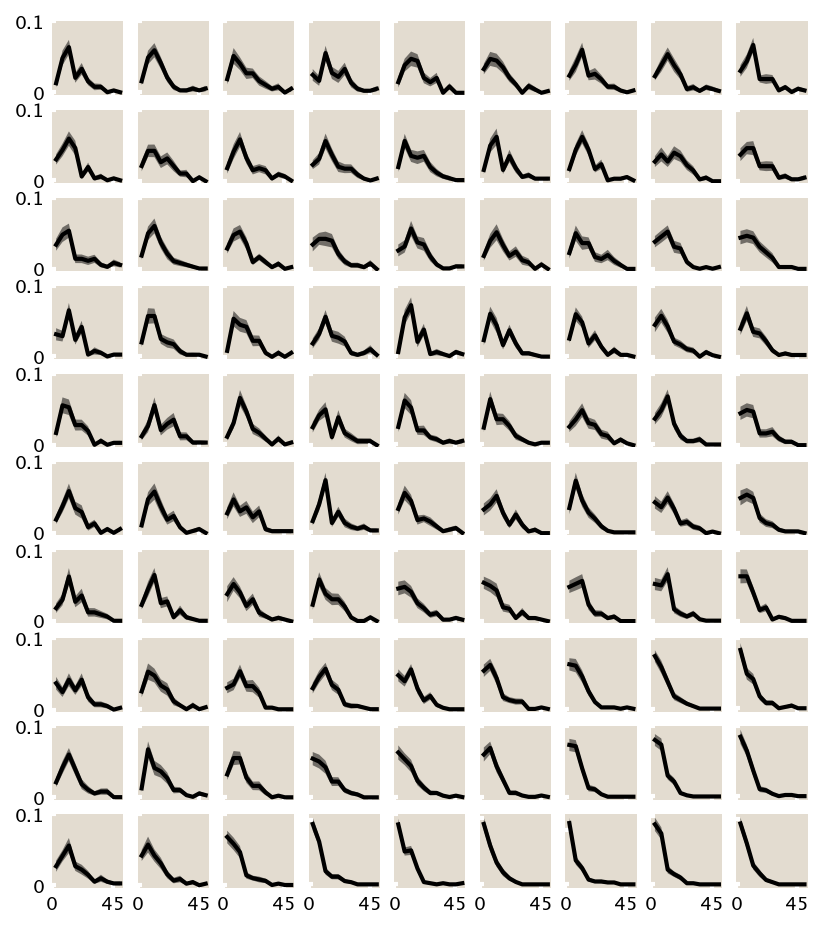

In [13]:
counter = 0
fig, axs = plt.subplots(len(detection_threshold_arr), len(noise_arr), figsize=(6.5, 7.5))
fontsize = 9
ratio_arr = np.zeros((len(detection_threshold_arr), len(noise_arr)))
xticks = (0, 45)
yticks = (0, 0.1)
for j in range(len(detection_threshold_arr)):
    for k in range(len(noise_arr)):
        with open(f'/home/brandon/Documents/Code/zebrafish-ms2-paper/data/parameter_sweeps/k_off/{counter}.pkl', 'rb') as file:
            data = pickle.load(file)
        inactive_durations = data['active_durations']
        _, prob_dens = plot_interval_dists(inactive_durations, bins, ax=axs[j, k], xticks=xticks, yticks=yticks)
        #_, prob_dens = plot_interval_dists(inactive_durations, bins, ax=axs[j, k], title=f'x={detection_threshold_arr[j]:.1f}, $\sigma$={noise_arr[k]:.1f}')
        ratio_arr[j, k] = np.max(prob_dens) / prob_dens[0]
        axs[j, k].tick_params(length=2)
        if k == 0:
            axs[j, k].set_yticks(yticks, labels=yticks)
            
        if j == len(detection_threshold_arr) - 1:
            axs[j, k].set_xticks(xticks, labels=xticks)
        counter += 1


In [204]:
#plt.savefig(r'/home/brandon/Documents/Code/zebrafish-ms2-paper/figures/k_off-active.pdf')

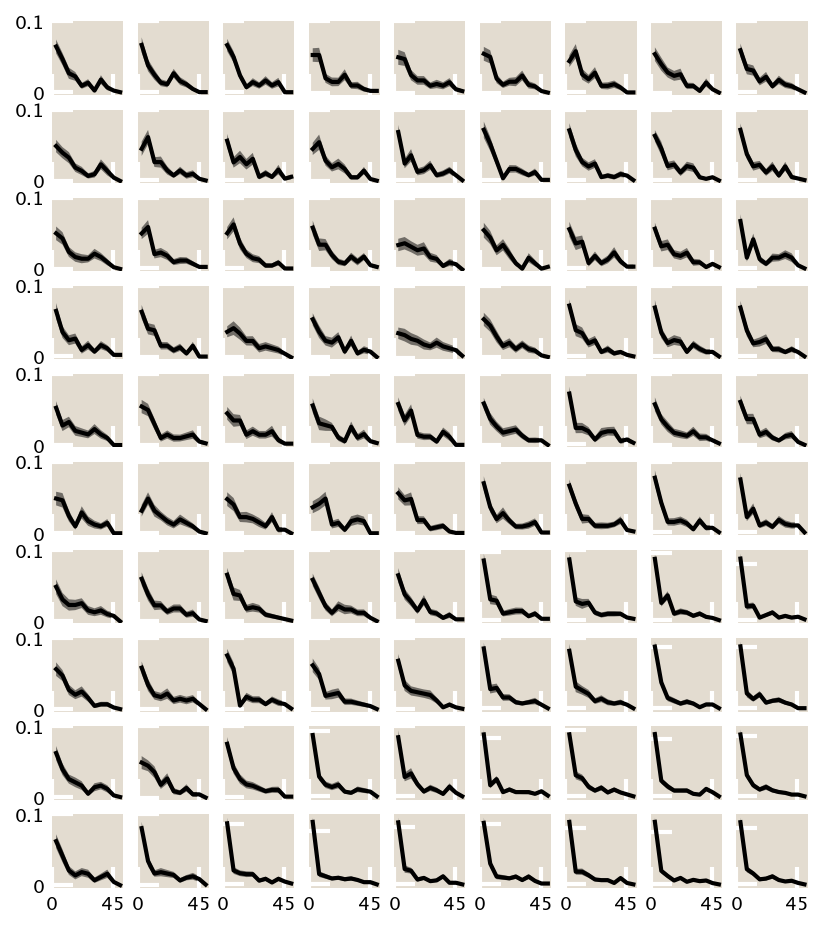

In [14]:
counter = 0
fig, axs = plt.subplots(len(detection_threshold_arr), len(noise_arr), figsize=(6.5, 7.5))
ratio_arr = np.zeros((len(detection_threshold_arr), len(noise_arr)))
for j in range(len(detection_threshold_arr)):
    for k in range(len(noise_arr)):
        with open(f'/home/brandon/Documents/Code/zebrafish-ms2-paper/data/parameter_sweeps/k_off/{counter}.pkl', 'rb') as file:
            data = pickle.load(file)
        inactive_durations = data['inactive_durations']
        _, prob_dens = plot_interval_dists(inactive_durations, bins, ax=axs[j, k], xticks=xticks, yticks=yticks)
        #_, prob_dens = plot_interval_dists(inactive_durations, bins, ax=axs[j, k], title=f'x={detection_threshold_arr[j]:.1f}, $\sigma$={noise_arr[k]:.1f}')
        ratio_arr[j, k] = np.max(prob_dens) / prob_dens[0]
        if k == 0:
            axs[j, k].set_yticks(yticks, labels=yticks)
            
        if j == len(detection_threshold_arr) - 1:
            axs[j, k].set_xticks(xticks, labels=xticks)
            
        counter += 1  


In [206]:
#plt.savefig(r'/home/brandon/Documents/Code/zebrafish-ms2-paper/figures/k_off-inactive.pdf')

## Make schematic fig
Illustrate the two paramters, noise strength and threshold

In [195]:
detection_threshold = 0.9
sigma = 0.8 
fontsize = 9

p = Params()
p.initial_state = np.array([1])
p.Tmax = 120
p.k_off0 = 0.08
p.k_off1 = 0.0
p.k_on0 = 0.0
p.k_on1 = 0.5
p.transcription_rate_0 = 10

p.translation_rate = 4.5
p.transcription_rate_1 = 0

p.mrna_decay_rate = 0.23
p.protein_decay_rate = 0.23

p.delay = 0.0

p.KD_k_on = 80
p.n = 3

X, tvec, p = simulate_multiple_copies(p)
burn_in_time = 0
X = X[burn_in_time:]
production_rate = p.transcription_rate_0 + p.transcription_rate_1 * hill_function(X[:,-1], p.KD_transcription_rate, p.n)
state = X[:, 0]

elongation_time = 0.29
delta_t=1.0
# MS2 memory parameter
w = elongation_time / delta_t

relevant_production_rate = production_rate[np.where(tvec > burn_in_time)[0]]
m = np.mean(np.log10(relevant_production_rate[relevant_production_rate > 0]))
s = np.std(np.log10(relevant_production_rate[relevant_production_rate > 0]))

detection_threshold = detection_threshold * 10 ** (m + s) * w

ms2_no_noise_no_threshold, uniform_times = sim_ms2(state, tvec, production_rate, w, delta_t, sigma=0, detection_threshold=0)
ms2_no_threshold, _ = sim_ms2(state, tvec, production_rate, w, delta_t, sigma=sigma, detection_threshold=0)
ms2 = ms2_no_threshold.copy()
ms2[ms2 < detection_threshold] = 0
inferred_state = binarize_trace(ms2, uniform_times, thresh=1e-1, window_size=3)

fig, axs = plt.subplots(3, 2, figsize=(6.5, 6.5))
ax = axs[0, 0]
ax.plot(tvec, state, linewidth=linewidth, color='k')
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$ \npromoter state', fontsize=fontsize)
ax.set_title('true $her1$ promoter state (ON/OFF)', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[0, 1]
ax.plot(uniform_times, ms2_no_noise_no_threshold, linewidth=linewidth, color=colors['red'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$-MS2 \nfluorescence intensity (a.u.)', fontsize=fontsize)
ax.set_title('true $her1$-MS2 signal', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[1, 0]
ax.plot(uniform_times, ms2_no_threshold, linewidth=linewidth, color=colors['purple'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$-MS2 \nfluorescence intensity (a.u.)', fontsize=fontsize)
ax.set_title('$her1$-MS2 with noise', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[1, 1]
ax.plot(uniform_times, ms2, linewidth=linewidth, color=colors['green'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$-MS2 \nfluorescence intensity (a.u.)', fontsize=fontsize)
ax.set_title('$her1$-MS2 with noise and detection threshold', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[2, 0]
ax.plot(uniform_times, inferred_state, '--', linewidth=linewidth, color=colors['blue'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$ \npromoter state', fontsize=fontsize)
ax.set_title('inferred $her1$ promoter state', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[2, 1]
ax.plot(tvec, state, linewidth=linewidth, color='k')
ax.plot(uniform_times, inferred_state, '--', linewidth=linewidth, color=colors['blue'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$ \npromoter state', fontsize=fontsize)
ax.set_title('true vs. inferred $her1$ promoter state', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

plt.tight_layout()

In [196]:
#plt.savefig(r'/home/brandon/Documents/Code/zebrafish-ms2-paper/figures/sim_ms2_noise_schematic.pdf')

In [192]:
detection_threshold = 0.9
sigma = 0.8 
fontsize = 9

p = Params()
p.initial_state = np.array([1])
p.Tmax = 120
p.k_off0 = 0.08
p.k_off1 = 0.0
p.k_on0 = 0.0
p.k_on1 = 0.5
p.transcription_rate_0 = 10

p.translation_rate = 4.5
p.transcription_rate_1 = 0

p.mrna_decay_rate = 0.23
p.protein_decay_rate = 0.23

p.delay = 0.0

p.KD_k_on = 80
p.n = 3

X, tvec, p = simulate_multiple_copies(p)
burn_in_time = 0
X = X[burn_in_time:]
production_rate = p.transcription_rate_0 + p.transcription_rate_1 * hill_function(X[:,-1], p.KD_transcription_rate, p.n)
state = X[:, 0]

elongation_time = 0.29
delta_t=1.0
# MS2 memory parameter
w = elongation_time / delta_t

relevant_production_rate = production_rate[np.where(tvec > burn_in_time)[0]]
m = np.mean(np.log10(relevant_production_rate[relevant_production_rate > 0]))
s = np.std(np.log10(relevant_production_rate[relevant_production_rate > 0]))

detection_threshold = detection_threshold * 10 ** (m + s) * w

ms2_no_noise_no_threshold, uniform_times = sim_ms2(state, tvec, production_rate, w, delta_t, sigma=0, detection_threshold=0)
ms2_no_threshold, _ = sim_ms2(state, tvec, production_rate, w, delta_t, sigma=sigma, detection_threshold=0)
ms2 = ms2_no_threshold.copy()
ms2[ms2 < detection_threshold] = 0
inferred_state = binarize_trace(ms2, uniform_times, thresh=1e-1, window_size=3)

fig, axs = plt.subplots(2, 3, figsize=(6.5, 3))
ax = axs[0, 0]
ax.plot(tvec, state, linewidth=linewidth, color='k')
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$ \npromoter \nstate', fontsize=fontsize)
ax.set_title('true $her1$ promoter state (ON/OFF)', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[0, 1]
ax.plot(uniform_times, ms2_no_noise_no_threshold, linewidth=linewidth, color=colors['red'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$-MS2 \nfluorescence \nintensity (a.u.)', fontsize=fontsize)
ax.set_title('true $her1$-MS2 signal', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[0, 2]
ax.plot(uniform_times, ms2_no_threshold, linewidth=linewidth, color=colors['purple'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$-MS2 \nfluorescence \nintensity (a.u.)', fontsize=fontsize)
ax.set_title('$her1$-MS2 with noise', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[1, 0]
ax.plot(uniform_times, ms2, linewidth=linewidth, color=colors['green'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$-MS2 \nfluorescence \nintensity (a.u.)', fontsize=fontsize)
ax.set_title('$her1$-MS2 with noise \nand detection threshold', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[1, 1]
ax.plot(uniform_times, inferred_state, '--', linewidth=linewidth, color=colors['blue'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$ \npromoter \nstate', fontsize=fontsize)
ax.set_title('inferred $her1$ promoter state', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

ax = axs[1, 2]
ax.plot(tvec, state, linewidth=linewidth, color='k')
ax.plot(uniform_times, inferred_state, '--', linewidth=linewidth, color=colors['blue'])
ax.set_xlabel('time (min)', fontsize=fontsize)
ax.set_ylabel('$her1$ \npromoter \nstate', fontsize=fontsize)
ax.set_title('true vs. inferred \n$her1$ promoter state', fontsize=fontsize)
ax = style_axes(ax, fontsize=fontsize)

plt.tight_layout()

## Plot even simpler schematic

In [214]:
detection_threshold = 0.5
sigma = 0.3 
fontsize = 9

p = Params()
p.initial_state = np.array([1])
p.Tmax = 120
p.k_off0 = 0.08
p.k_off1 = 0.0
p.k_on0 = 0.0
p.k_on1 = 0.5
p.transcription_rate_0 = 10

p.translation_rate = 4.5
p.transcription_rate_1 = 0

p.mrna_decay_rate = 0.23
p.protein_decay_rate = 0.23

p.delay = 0.0

p.KD_k_on = 80
p.n = 3

X, tvec, p = simulate_multiple_copies(p)
burn_in_time = 0
X = X[burn_in_time:]
production_rate = p.transcription_rate_0 + p.transcription_rate_1 * hill_function(X[:,-1], p.KD_transcription_rate, p.n)
state = X[:, 0]

elongation_time = 0.29
delta_t=1.0
# MS2 memory parameter
w = elongation_time / delta_t

relevant_production_rate = production_rate[np.where(tvec > burn_in_time)[0]]
m = np.mean(np.log10(relevant_production_rate[relevant_production_rate > 0]))
s = np.std(np.log10(relevant_production_rate[relevant_production_rate > 0]))

detection_threshold = detection_threshold * 10 ** (m + s) * w

ms2, uniform_times= sim_ms2(state, tvec, production_rate, w, delta_t, sigma=sigma, detection_threshold=detection_threshold)

plt.figure(figsize=(3,2))
plt.plot(uniform_times, ms2, linewidth=2, color=colors['green'])
plt.plot(uniform_times, detection_threshold * np.ones_like(uniform_times), '--', linewidth=2, color=(0.5, 0.5, 0.5))
plt.xlabel("time (min)", fontsize=fontsize)
plt.ylabel('simulated \n$her1$-MS2 \nfluorescence \nintensity (a.u.)', fontsize=fontsize)
ax = style_axes(plt.gca(), fontsize=fontsize)
plt.tight_layout()

In [215]:
plt.savefig(r'/home/brandon/Documents/Code/zebrafish-ms2-paper/figures/sim_ms2_simplified_schematic.pdf')